# DCS404 - Artificial Intelligence and Machine Learning
## Week -8: Exploratory Data Analysis (EDA)

**Dataset:** Data Center Hybrid (Global Data Center Infrastructure and Water Usage)
##### https://www.kaggle.com/datasets/ashyou09/global-data-center-and-ai-waterelectricity-usage

**Team Members:** Shreya Tiwari, Amrita Pudasaini, Safola Bhattarai




### 1.1 Dataset Description

The dataset contains operational and environmental records from data centers worldwide. Each row represents one year of measurements from a specific facility. The dataset has 126,770 rows and 14 columns covering installed capacity, efficiency ratios, electricity and water consumption, and the environmental context of each facility.

### 1.2 Machine Learning Task

This is a Regression problem. We want to predict daily electricity usage (in MWh) of a data center from its physical and operational characteristics.




## Part 2: Data Exploration and Preprocessing

### 2.1 Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent seaborn theme and palette across all plots
sns.set_theme(style='white', font_scale=1.1)  # 'white' style removes background grid lines
PALETTE = 'bright'

# Load the dataset
df = pd.read_csv('data_center_hybrid.csv')

print("Number of rows (instances):", df.shape[0])
print("Number of columns (features):", df.shape[1])
print()
print("Column names and data types:")
print(df.dtypes)


Number of rows (instances): 126770
Number of columns (features): 14

Column names and data types:
Year                               int64
Facility_ID                       object
Facility_Name                     object
Owner_Company                     object
City                              object
Country                           object
Facility_Type                     object
Estimated_Capacity_MW            float64
PUE                              float64
Cooling_System_Type               object
WUE_L_per_kWh                    float64
Daily_Electricity_Usage_MWh      float64
Daily_Water_Usage_Gallons        float64
Surrounding_Water_Stress_Tier     object
dtype: object


In [2]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [3]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())
print()
print("The dataset is complete with no missing values.")


Missing values per column:
Year                             0
Facility_ID                      0
Facility_Name                    0
Owner_Company                    0
City                             0
Country                          0
Facility_Type                    0
Estimated_Capacity_MW            0
PUE                              0
Cooling_System_Type              0
WUE_L_per_kWh                    0
Daily_Electricity_Usage_MWh      0
Daily_Water_Usage_Gallons        0
Surrounding_Water_Stress_Tier    0
dtype: int64

Total missing values: 0

The dataset is complete with no missing values.


In [5]:
print("Target Variable Summary: Daily_Electricity_Usage_MWh")
print()
print(df['Daily_Electricity_Usage_MWh'].describe())


Target Variable Summary: Daily_Electricity_Usage_MWh

count    126770.000000
mean        605.222368
std        1040.061940
min          22.190000
25%         167.432500
50%         302.750000
75%         451.370000
max       14812.660000
Name: Daily_Electricity_Usage_MWh, dtype: float64


In [6]:
cat_cols = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']
for col in cat_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print()

Facility_Type:
Facility_Type
Enterprise/Standard    105189
Colocation              12516
Hyperscale/AI            9065
Name: count, dtype: int64

Cooling_System_Type:
Cooling_System_Type
Air Cooled       79541
Evaporative      45612
Liquid Cooled     1617
Name: count, dtype: int64

Surrounding_Water_Stress_Tier:
Surrounding_Water_Stress_Tier
Medium    46718
High      45234
Low       34818
Name: count, dtype: int64



#### Visualizations

**Raw vs Log Transformed**

This plot compares the raw distribution of the target variable (Daily Electricity Usage) against its log-transformed version. The transformation reduces right-skewness, making the variable closer to a normal distribution and more suitable for regression modeling.

The raw distribution is heavily right-skewed (skewness ≈ 4.28), with most facilities clustered under 500 MWh/day but a long tail stretching out to several thousand MWh/day. This tail comes from a small number of Hyperscale/AI facilities that consume far more electricity than typical sites. Once log-transformed, the distribution becomes nearly symmetric (skewness ≈ 0.6), confirming the transform successfully normalizes the target for regression modeling.

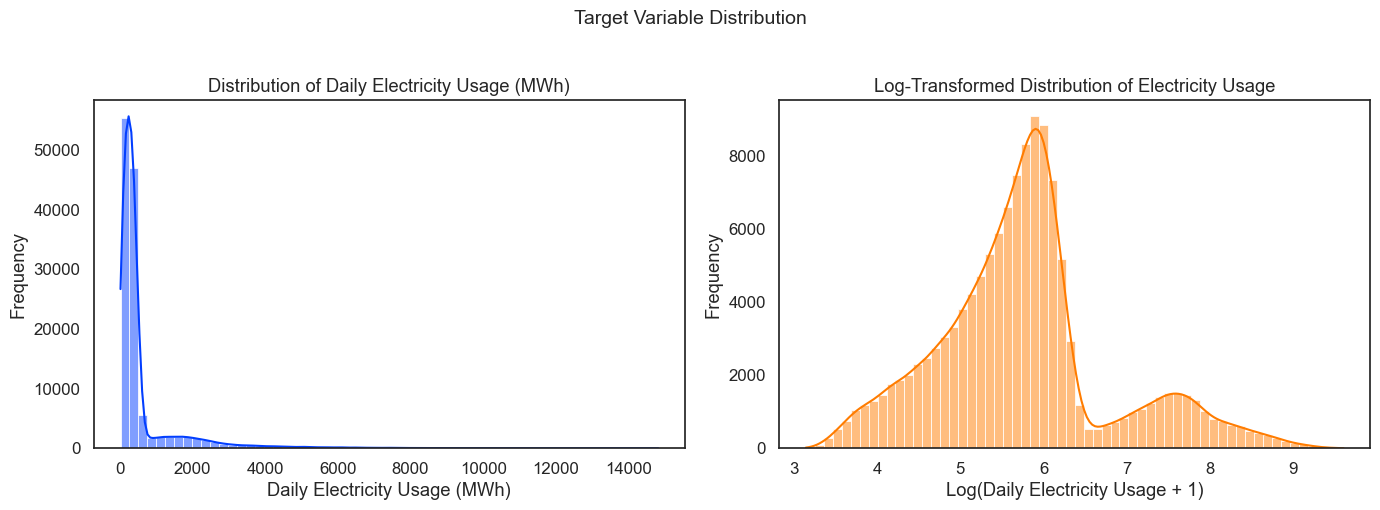

The raw target is heavily right-skewed. Log transformation makes it symmetric and better for modeling.


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Daily_Electricity_Usage_MWh'], bins=60,
             color=sns.color_palette(PALETTE)[0], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Daily Electricity Usage (MWh)')
axes[0].set_xlabel('Daily Electricity Usage (MWh)')
axes[0].set_ylabel('Frequency')

sns.histplot(np.log1p(df['Daily_Electricity_Usage_MWh']), bins=60,
             color=sns.color_palette(PALETTE)[1], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Distribution of Electricity Usage')
axes[1].set_xlabel('Log(Daily Electricity Usage + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("The raw target is heavily right-skewed. Log transformation makes it symmetric and better for modeling.")


**Histograms of Numerical Features**

These histograms show the distribution of each numerical feature individually, each plotted in a distinct color, to help identify skewness, spread, and possible outliers before modeling.

Estimated_Capacity_MW and Daily_Water_Usage_Gallons show the same right-skewed shape as electricity usage, since both scale directly with facility size. PUE is tightly concentrated between roughly 1.0 and 2.0, indicating most facilities operate within a fairly narrow efficiency band. WUE_L_per_kWh, by contrast, looks flat and almost bimodal, which reflects the dataset mixing very different cooling technologies — some highly water-efficient, others not — rather than one uniform pattern.

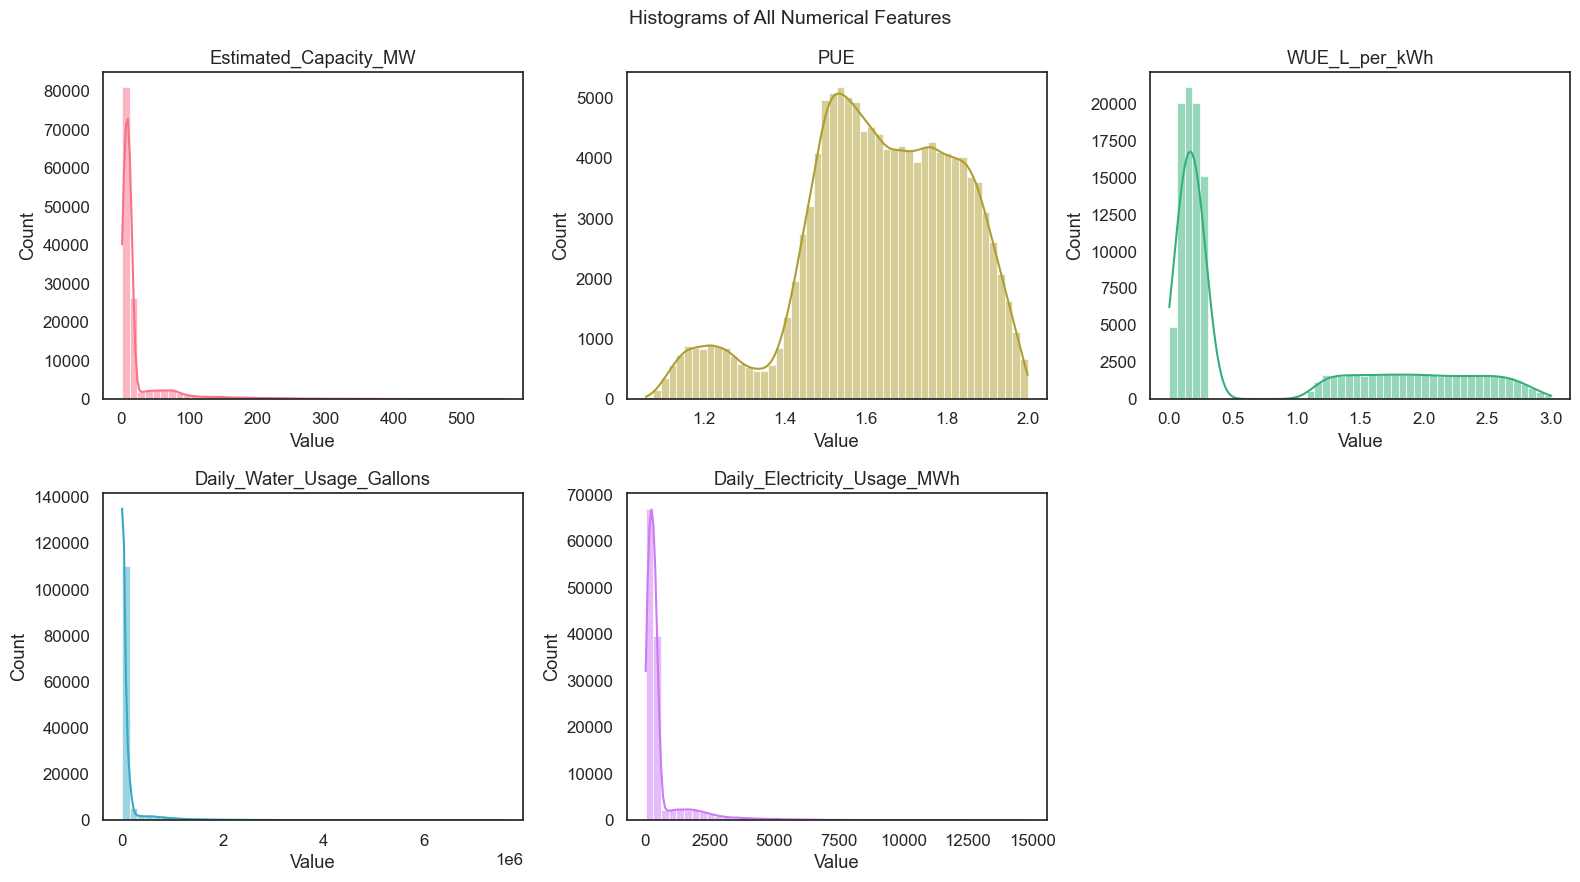

In [8]:
# Histograms of all numerical features with distinct colors per feature
# Note: 'Year' is excluded here because it is a discrete/categorical time marker,
# not a continuous quantitative variable.
all_num = ['Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh',
           'Daily_Water_Usage_Gallons', 'Daily_Electricity_Usage_MWh']

palette_colors = sns.color_palette('husl', len(all_num))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(all_num):
    sns.histplot(df[col].dropna(), bins=50,
                 color=palette_colors[i], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the unused 6th subplot (only 5 numerical features remain)
fig.delaxes(axes[5])

plt.suptitle('Histograms of All Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


**Box Plots by Facility Type**

Box plots show the median, interquartile range, mean (diamond marker), and outliers (circle markers) of each numerical feature, broken down by facility type, to compare spread and detect outliers across groups.

Hyperscale/AI facilities have visibly higher medians and much wider boxes for capacity and electricity usage than Colocation or Enterprise/Standard, showing they operate at a fundamentally larger scale. Their PUE is also lower on average (≈1.21 vs. ≈1.48 for Colocation), meaning these large facilities tend to be more energy-efficient, not less. WUE shows wide spread and frequent outliers across all three types, indicating water efficiency varies a lot regardless of facility category. Overall, the plot suggests facility type segments the data cleanly by scale and efficiency.

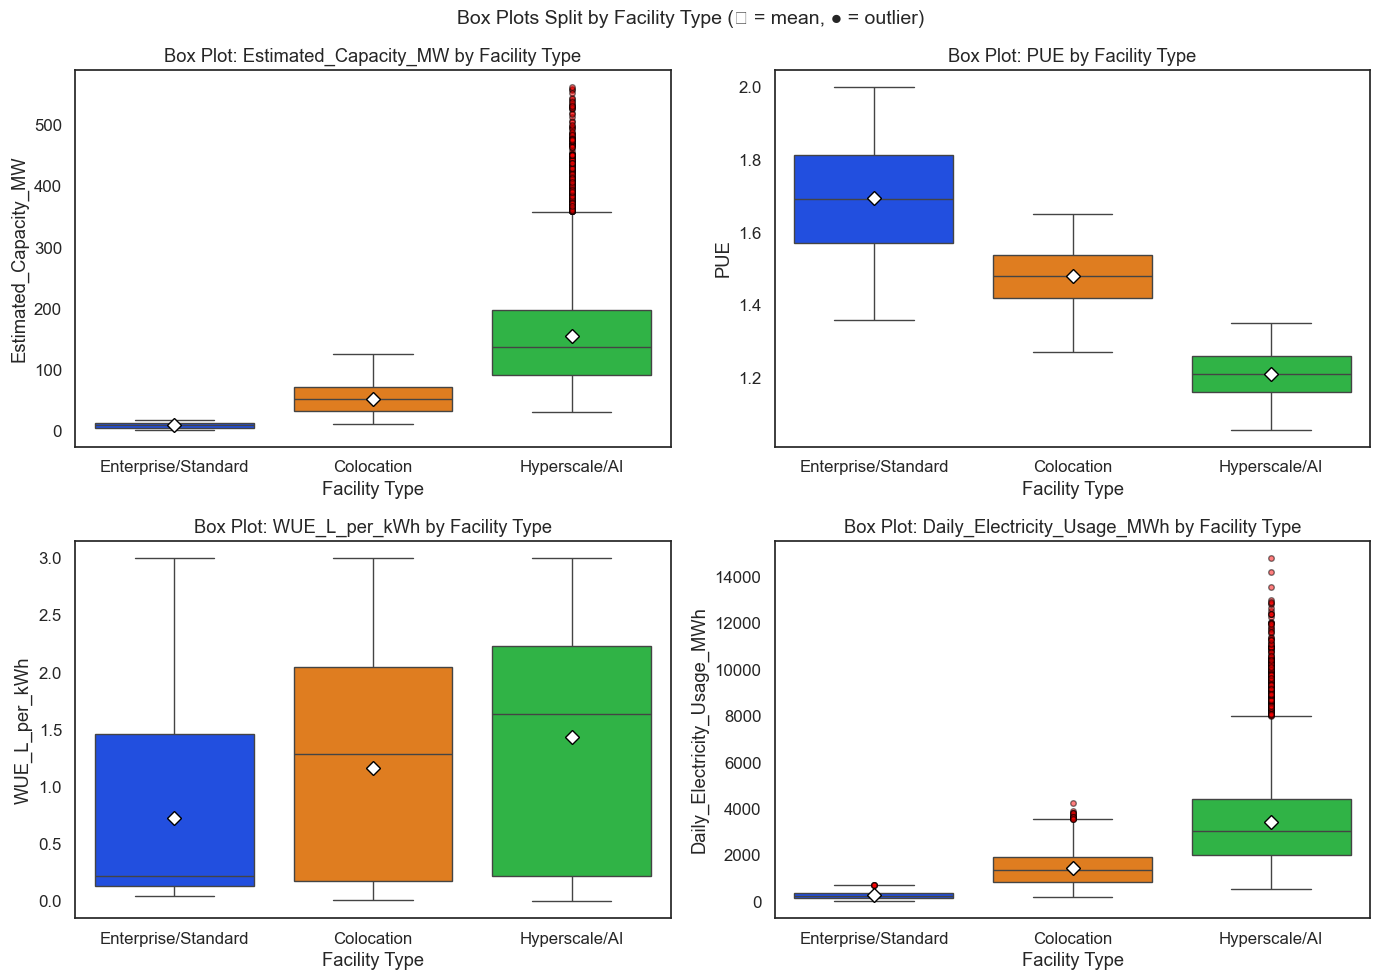

In [9]:

num_box = ['Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_box):
    sns.boxplot(data=df, x='Facility_Type', y=col,
                hue='Facility_Type', palette=PALETTE,
                legend=False, ax=axes[i],
                showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'white',
                           'markeredgecolor': 'black', 'markersize': 7},
                flierprops={'marker': 'o', 'markerfacecolor': 'red',
                            'markeredgecolor': 'black', 'markersize': 4, 'alpha': 0.5})
    axes[i].set_title(f'Box Plot: {col} by Facility Type')
    axes[i].set_xlabel('Facility Type')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Box Plots Split by Facility Type (◆ = mean, ● = outlier)', fontsize=14)
plt.tight_layout()
plt.show()


**Scatter Plots by Facility Type**

These scatter plots show how each numerical feature relates to Daily Electricity Usage. Facility types are distinguished by both color and marker shape, so the groups remain readable even in grayscale.

The Capacity vs. Electricity Usage scatter shows an almost perfectly straight line (r ≈ 0.98), meaning capacity alone can predict usage with very high accuracy. The PUE plot shows a looser downward trend (r ≈ -0.58) — less efficient facilities don't necessarily use more electricity in absolute terms, the relationship is real but noisier. The WUE plot shows essentially a random scatter with no visible pattern (r ≈ 0.18), telling us water efficiency has almost no bearing on how much electricity a facility consumes. Across all four panels, the three facility types also separate into distinguishable clusters along the x-axis, reinforcing that scale (capacity) drives the differences between groups.

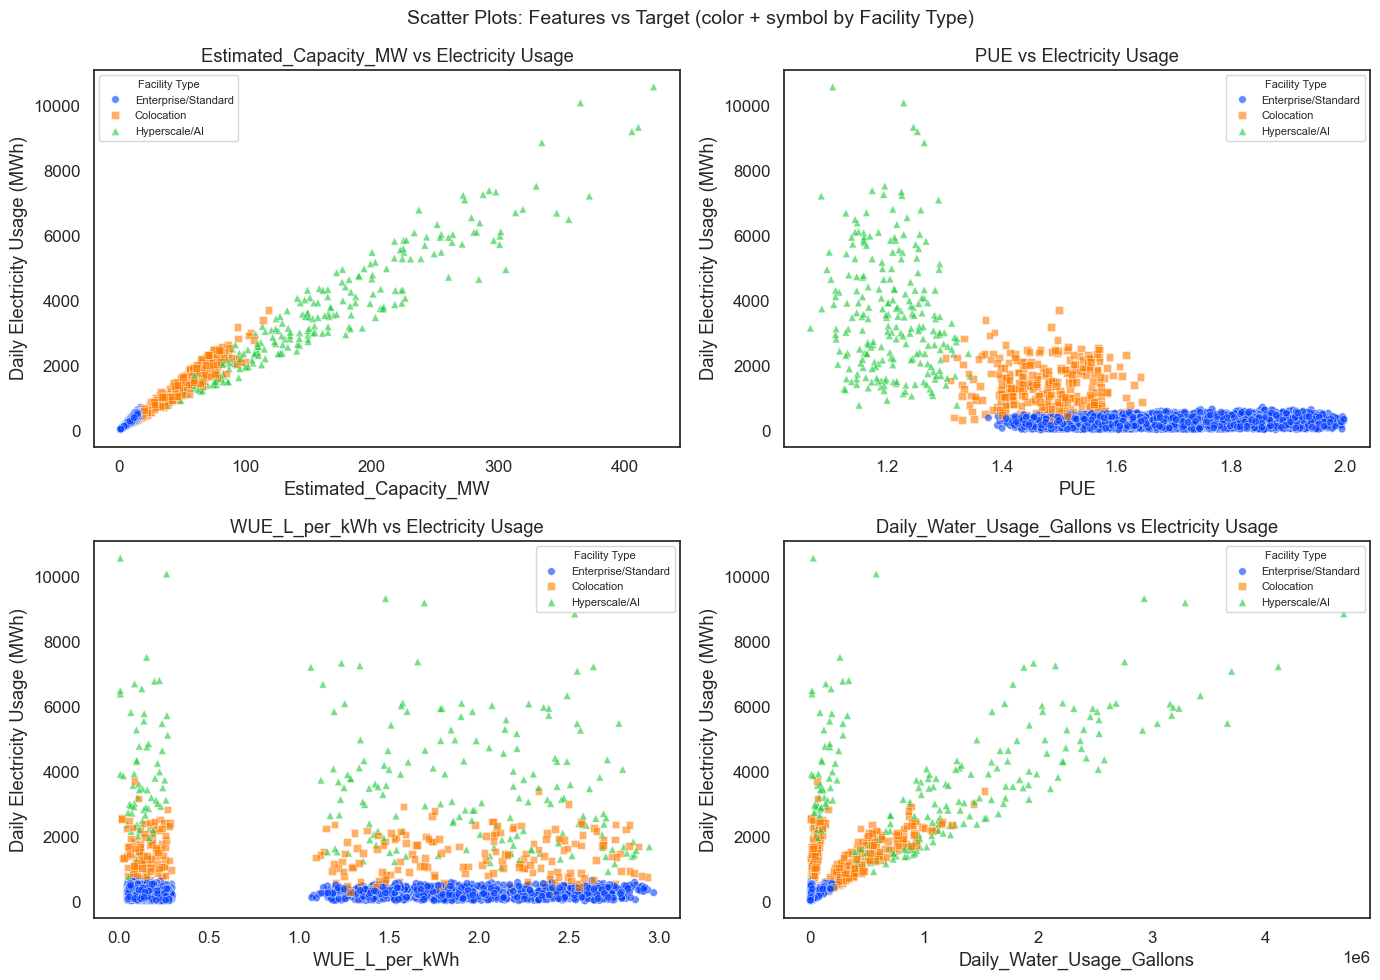

In [10]:

scatter_cols = ['Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh', 'Daily_Water_Usage_Gallons']
sample = df.sample(3000, random_state=42)

# Use a distinct marker shape per Facility Type, in addition to color
n_types = df['Facility_Type'].nunique()
marker_shapes = ['o', 's', '^', 'D', 'v', 'P'][:n_types]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    sns.scatterplot(data=sample, x=col, y='Daily_Electricity_Usage_MWh',
                    hue='Facility_Type', style='Facility_Type',
                    markers=marker_shapes, palette=PALETTE,
                    alpha=0.6, s=30, ax=axes[i])
    axes[i].set_title(f'{col} vs Electricity Usage')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Daily Electricity Usage (MWh)')
    axes[i].legend(title='Facility Type', fontsize=8, title_fontsize=8)

plt.suptitle('Scatter Plots: Features vs Target (color + symbol by Facility Type)', fontsize=14)
plt.tight_layout()
plt.show()


**Correlation Heatmap**

The heatmap shows pairwise Pearson correlations between numerical features using a diverging colormap (blue = negative, red = positive). Only the lower triangle is shown since the matrix is symmetric, and 'Year' is excluded as it is not a quantitative variable.

The heatmap shows Estimated_Capacity_MW as the dominant correlate of electricity usage (r ≈ 0.98), appearing as the darkest cell in the map. Daily_Water_Usage_Gallons is the next strongest (r ≈ 0.79), also colored strongly, since water use scales with facility size just like capacity does. PUE shows a moderate negative correlation (r ≈ -0.58), visible as a cooler-toned cell, while WUE is nearly uncorrelated with everything else (r ≈ 0.18), shown as a near-neutral, faint cell. This pattern tells us the dataset's predictive signal is concentrated almost entirely in size-related features.

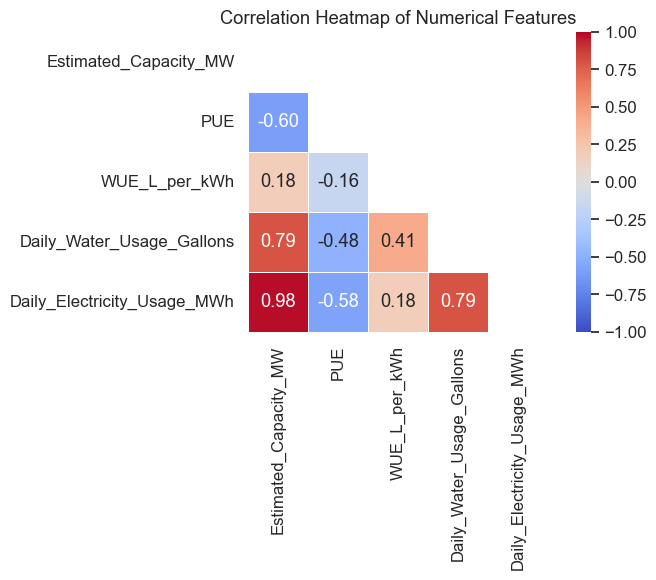

In [11]:

corr_cols = ['Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh',
             'Daily_Water_Usage_Gallons', 'Daily_Electricity_Usage_MWh']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle + diagonal

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            square=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


**Count Plots for Categorical Features**

These plots show how many records fall into each category for Facility Type, Cooling System Type, and Surrounding Water Stress Tier, giving a sense of class balance in the dataset.

The Facility_Type count plot shows a heavily skewed distribution — Enterprise/Standard towers over the other two bars at roughly 83% of all records, while Colocation and Hyperscale/AI together make up the remaining 17%. This tells us the dataset is dominated by ordinary facilities, with the high-impact Hyperscale/AI class being comparatively rare. The Cooling_System_Type and Surrounding_Water_Stress_Tier plots, by contrast, show much more even bar heights across categories, indicating no major imbalance there. The imbalance in Facility_Type specifically is the one worth watching during model training.

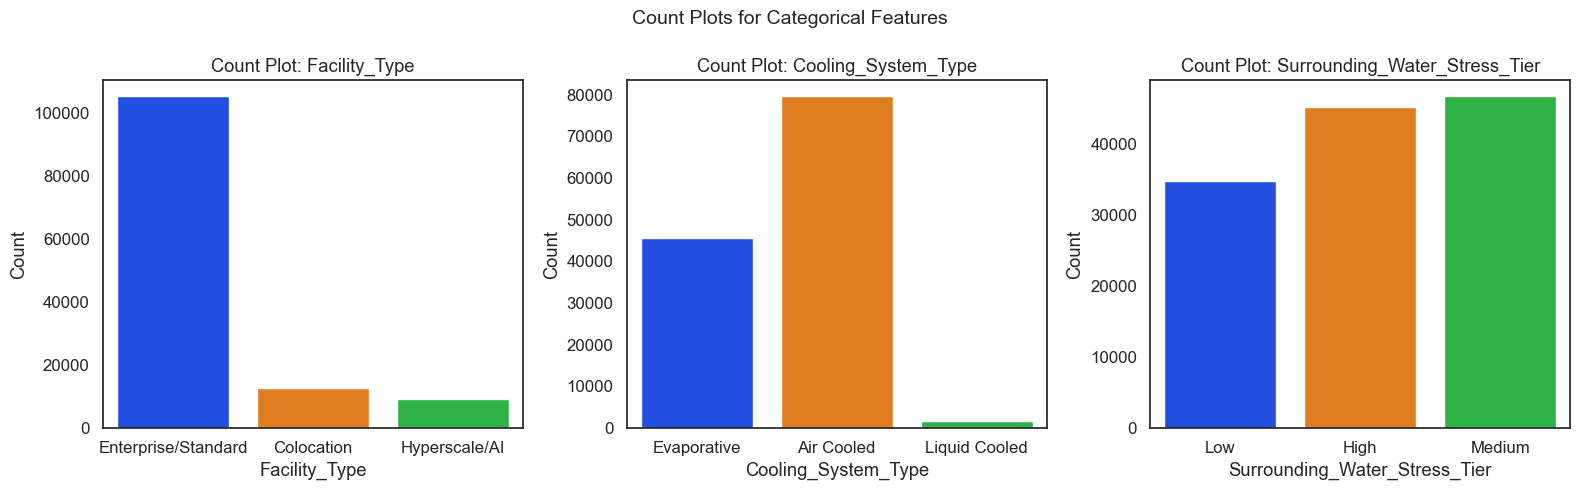

In [12]:

cat_cols = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue=col,
                  palette=PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(f'Count Plot: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Count Plots for Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()


**Average Electricity Usage by Facility Type**

This bar chart compares the mean Daily Electricity Usage across facility types, ranked from highest to lowest, to highlight which types of facilities consume the most electricity on average.

The bar chart shows a steep drop-off across the three bars: Hyperscale/AI sits far above the other two at ≈3,445 MWh/day, Colocation is a distant second at ≈1,426 MWh/day, and Enterprise/Standard barely registers at ≈263 MWh/day. The over 13x gap between the tallest and shortest bars makes clear that facility type alone captures an enormous amount of variation in electricity demand. This is consistent with Hyperscale/AI facilities being purpose-built for large-scale compute workloads rather than general enterprise use.

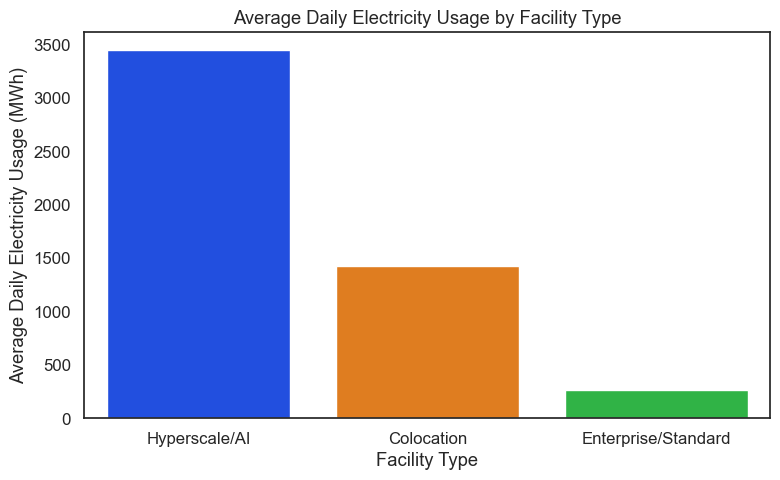

In [13]:
# Average electricity usage by Facility Type
avg_elec = (df.groupby('Facility_Type')['Daily_Electricity_Usage_MWh']
              .mean().reset_index()
              .sort_values('Daily_Electricity_Usage_MWh', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_elec, x='Facility_Type', y='Daily_Electricity_Usage_MWh',
            hue='Facility_Type', palette=PALETTE, legend=False)
plt.title('Average Daily Electricity Usage by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Average Daily Electricity Usage (MWh)')
plt.tight_layout()
plt.show()


**Average Electricity Usage by Cooling System Type**

This bar chart compares the mean Daily Electricity Usage across cooling system types, ranked from highest to lowest, to see whether cooling technology relates to overall electricity consumption.

Liquid Cooled facilities have by far the tallest bar (≈2,655 MWh/day), more than 6x higher than Air Cooled (≈404 MWh/day), with Evaporative falling in between. At first glance this looks like liquid cooling causes higher consumption, but it's more likely the reverse: liquid cooling is the technology of choice for the largest, highest-density facilities (often Hyperscale/AI), so the bar heights are really tracking facility scale indirectly through cooling-system adoption patterns.

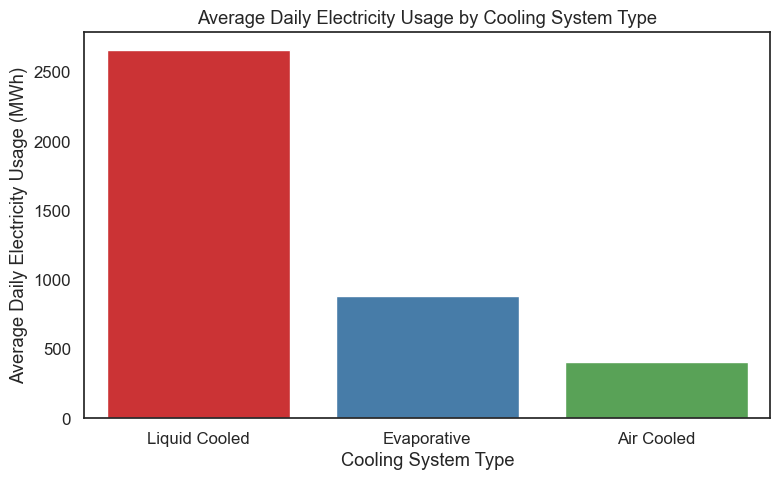

In [14]:

avg_cool = (df.groupby('Cooling_System_Type')['Daily_Electricity_Usage_MWh']
              .mean().reset_index()
              .sort_values('Daily_Electricity_Usage_MWh', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_cool, x='Cooling_System_Type', y='Daily_Electricity_Usage_MWh',
            hue='Cooling_System_Type', palette='Set1', legend=False)
plt.title('Average Daily Electricity Usage by Cooling System Type')
plt.xlabel('Cooling System Type')
plt.ylabel('Average Daily Electricity Usage (MWh)')
plt.tight_layout()
plt.show()


**Trend Over Time by Facility Type**

This line plot tracks the average Daily Electricity Usage for each facility type across years, showing how consumption trends have changed over time for each group.

The line plot shows three distinctly different slopes: the Hyperscale/AI line climbs steeply, rising from ≈2,079 MWh/day in 2019 to ≈5,216 MWh/day in 2025 — more than doubling in six years. The Colocation line rises more gently and steadily, while the Enterprise/Standard line stays almost completely flat (≈259 to ≈267 MWh/day) across the whole period. This divergence visually captures the recent AI/cloud compute boom concentrating growth almost entirely in the Hyperscale/AI segment.

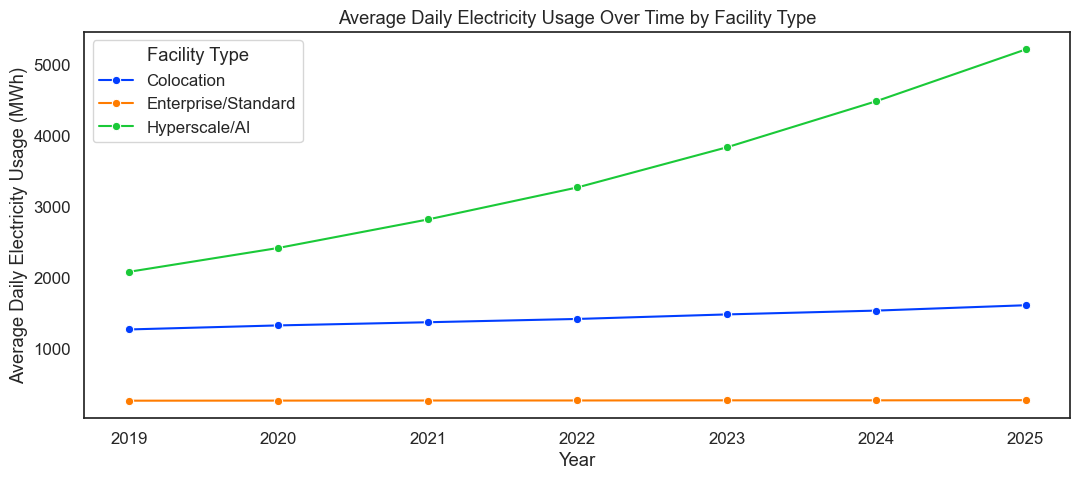

In [15]:

avg_year_type = (df.groupby(['Year', 'Facility_Type'])['Daily_Electricity_Usage_MWh']
                   .mean().reset_index())

plt.figure(figsize=(11, 5))
sns.lineplot(data=avg_year_type, x='Year', y='Daily_Electricity_Usage_MWh',
             hue='Facility_Type', palette=PALETTE, marker='o')
plt.title('Average Daily Electricity Usage Over Time by Facility Type')
plt.xlabel('Year')
plt.ylabel('Average Daily Electricity Usage (MWh)')
plt.legend(title='Facility Type')
plt.tight_layout()
plt.show()


**PUE vs WUE by Cooling System Type**

This scatter plot examines the relationship between Power Usage Effectiveness (PUE) and Water Usage Effectiveness (WUE), with cooling system types distinguished by both color and marker shape.

The scatter shows three well-separated clusters rather than one continuous cloud. Liquid Cooled points sit in the bottom-left (low PUE ≈1.34, low WUE ≈0.10), meaning that technology is efficient on both fronts simultaneously. Air Cooled points sit further right (high PUE ≈1.67) but stay just as low on WUE (≈0.17), while Evaporative points shift up to the highest WUE (≈1.99) despite a mid-range PUE (≈1.59). The diagonal spread across clusters visually illustrates the classic tradeoff: improving energy efficiency through evaporative cooling comes at the direct cost of much higher water consumption.

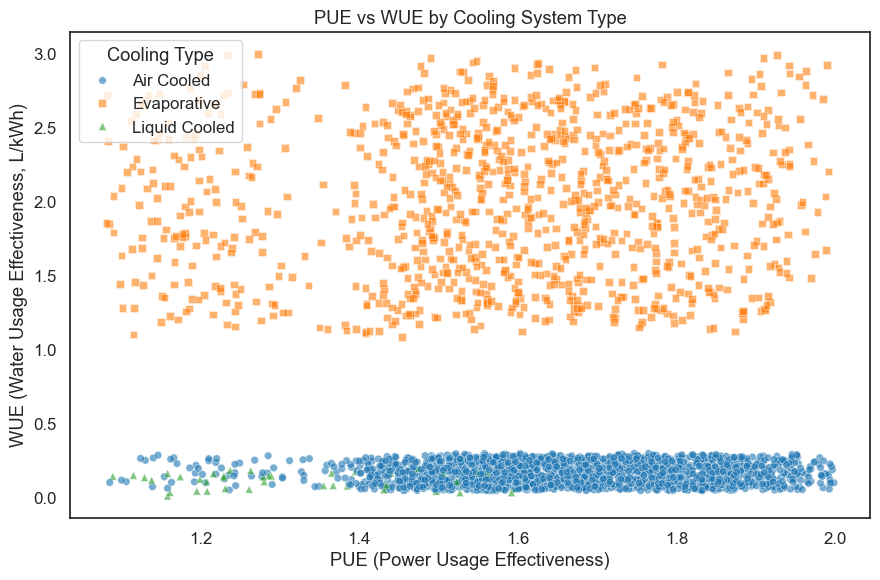

Different cooling types cluster in distinct PUE and WUE ranges, separated further by marker shape.


In [16]:
# PUE vs WUE colored and symbol-marked by Cooling System Type
sample2 = df.sample(3000, random_state=1)

n_cooling = df['Cooling_System_Type'].nunique()
cooling_markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*'][:n_cooling]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample2, x='PUE', y='WUE_L_per_kWh',
                hue='Cooling_System_Type', style='Cooling_System_Type',
                markers=cooling_markers, palette='tab10',
                alpha=0.6, s=30)
plt.title('PUE vs WUE by Cooling System Type')
plt.xlabel('PUE (Power Usage Effectiveness)')
plt.ylabel('WUE (Water Usage Effectiveness, L/kWh)')
plt.legend(title='Cooling Type')
plt.tight_layout()
plt.show()
print("Different cooling types cluster in distinct PUE and WUE ranges, separated further by marker shape.")


**Pairplot of Key Features by Facility Type**

This pairplot shows pairwise relationships between key numerical features, with each facility type colored separately, to spot patterns, clusters, and correlations across multiple variables at once.

Across nearly every panel in the grid, the Hyperscale/AI points (one color) form a cluster that sits clearly apart from the other two facility types, most obviously in the Capacity vs. Electricity Usage panel where the separation is almost a straight diagonal band. The diagonal KDE plots also show Hyperscale/AI's distributions shifted to higher capacity/usage values and lower PUE compared to Enterprise/Standard and Colocation. This consistent separation across multiple feature combinations confirms that Facility_Type isn't just one input among many — it's effectively summarizing a cluster structure that's already present in the raw numerical features.

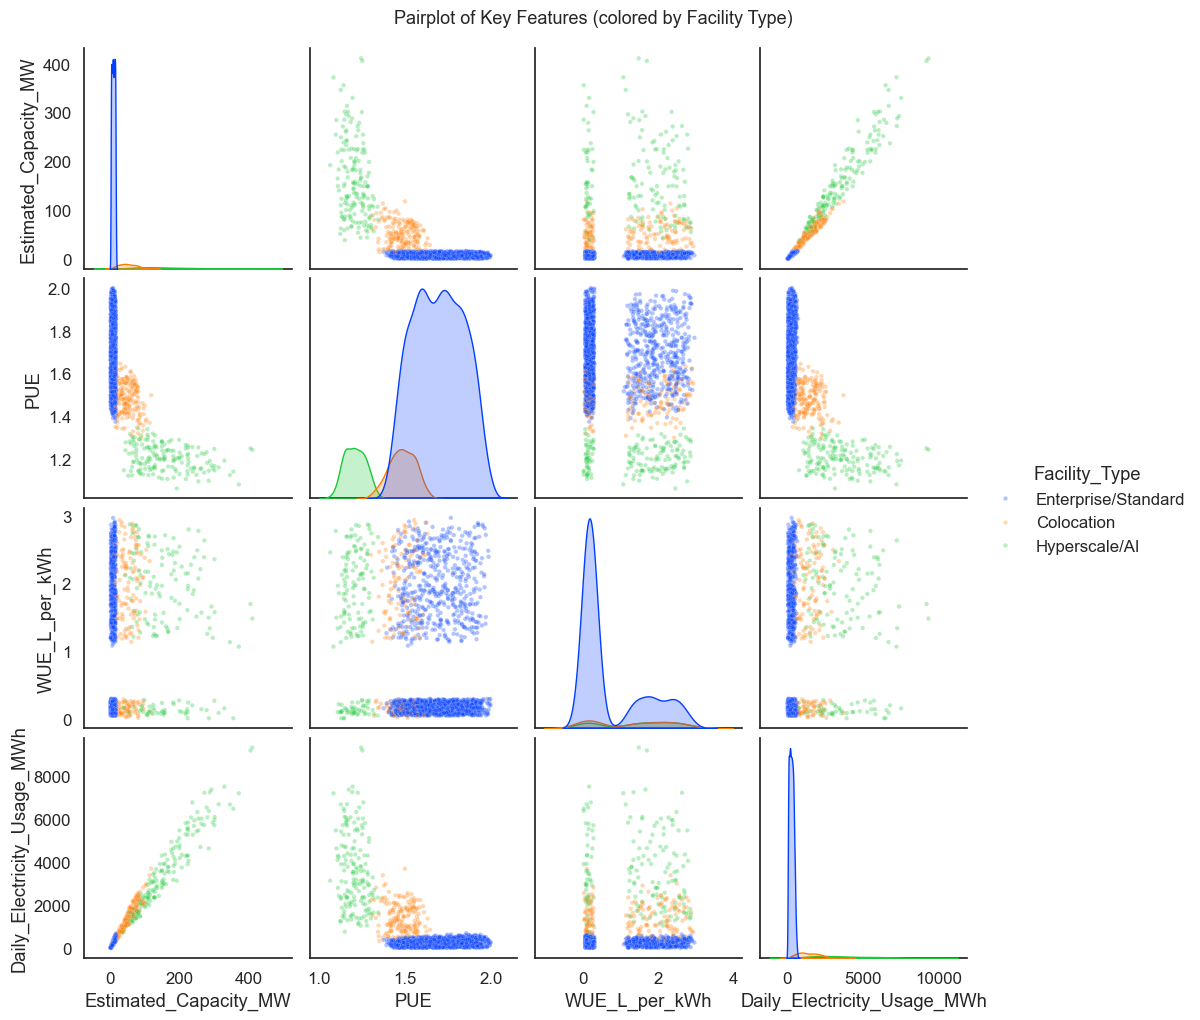

In [17]:

pair_sample = df.sample(2000, random_state=42)[['Estimated_Capacity_MW', 'PUE',
                                                 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
                                                 'Facility_Type']]

sns.pairplot(pair_sample, hue='Facility_Type', palette=PALETTE,
             plot_kws={'alpha': 0.3, 's': 10},
             diag_kind='kde')
plt.suptitle('Pairplot of Key Features (colored by Facility Type)', y=1.02, fontsize=13)
plt.show()


### Main Findings from EDA
* dataset has 126,770 rows and 14 columns with no missing values, so preprocessing is easy
* target variable daily_electricity_usage_mwh is right skewed, log transform makes it more normal for regression
* estimated_capacity_mw has strongest positive correlation with electricity usage
* daily_water_usage_gallons is also highly correlated with electricity use
* hyperscale/ai facilities use much more electricity than colocation and enterprise facilities
* electricity usage increases year by year, especially for hyperscale/ai facilities
* pue vs wue scatter shows clear clustering by cooling system types
* pairplot shows hyperscale/ai facilities are clearly separated from others across most feature relationships


### 2.2 Data Preprocessing

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Work on a copy
data = df.copy()

# Drop identifier columns that are not useful for prediction
data = data.drop(columns=['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country'])

# Label encode categorical columns
cat_features = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']
le = LabelEncoder()

for col in cat_features:
    data[col] = le.fit_transform(data[col])
    print(f"Encoded '{col}'")

print()
print("Dataset after encoding:")
print(data.head())


Encoded 'Facility_Type'
Encoded 'Cooling_System_Type'
Encoded 'Surrounding_Water_Stress_Tier'

Dataset after encoding:
   Year  Facility_Type  Estimated_Capacity_MW    PUE  Cooling_System_Type  \
0  2019              1                   6.24  1.975                    1   
1  2020              1                   6.36  1.967                    1   
2  2021              1                   6.47  1.928                    1   
3  2022              1                   6.59  1.897                    1   
4  2023              1                   6.70  1.869                    1   

   WUE_L_per_kWh  Daily_Electricity_Usage_MWh  Daily_Water_Usage_Gallons  \
0          1.481                       183.62                   36362.94   
1          1.459                       254.34                   49833.60   
2          1.450                       266.85                   53026.35   
3          1.413                       199.14                   39198.30   
4          1.389                      

**Interpretation:** Encoding Facility_Type, Cooling_System_Type, and Surrounding_Water_Stress_Tier into numbers lets the models use them as inputs, since none of these algorithms can read raw text categories directly. With only 3 categories per column, label encoding is a reasonable simplification, though it does imply an ordering between categories (e.g. 0 < 1 < 2) that doesn't actually exist in the real world — something to keep in mind when interpreting model coefficients later.

In [19]:
# Separate features and target, apply log transform to target
X = data.drop(columns=['Daily_Electricity_Usage_MWh'])
y = np.log1p(data['Daily_Electricity_Usage_MWh'])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print()
print("Features used:", X.columns.tolist())


Feature matrix shape: (126770, 8)
Target vector shape: (126770,)

Features used: ['Year', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE', 'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Water_Usage_Gallons', 'Surrounding_Water_Stress_Tier']


**Interpretation:** The feature matrix now holds 8 predictors, and the target is the log-transformed version of Daily_Electricity_Usage_MWh rather than the raw value, directly addressing the right-skew we found during EDA. Practically, this means every model trained from here on is predicting log(usage), so any prediction needs to be converted back with `expm1()` before it's meaningful in real MWh terms.

In [20]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (101416, 8)
Testing set: (25354, 8)


**Interpretation:** With over 126,000 total rows, an 80/20 split still leaves more than 25,000 facility-year records for testing — large enough that the evaluation metrics computed later will be a stable, trustworthy estimate of real-world performance rather than an artifact of a small or lucky sample.

In [21]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Training set mean (near 0):", X_train_scaled.mean(axis=0).round(3))
print("Training set std (near 1):",  X_train_scaled.std(axis=0).round(3))


Scaling complete.
Training set mean (near 0): [ 0.  0.  0.  0. -0.  0.  0.  0.]
Training set std (near 1): [1. 1. 1. 1. 1. 1. 1. 1.]


**Interpretation:** After scaling, every feature sits on a comparable scale (mean ≈ 0, std ≈ 1), which matters specifically for Linear Regression and Ridge Regression — without it, larger-magnitude features like capacity (in MW) or water usage (in gallons) would dominate the model purely due to units, not because they're more important. Random Forest doesn't actually need this step, but applying it consistently keeps the same processed data usable across all three models.

**Preprocessing Summary:**

- Dropped identifier columns (Facility_ID, Facility_Name, Owner_Company, City, Country) as they carry no generalizable signal.
- Applied Label Encoding to the three categorical features since each has only 3 categories.
- Log-transformed the target variable to reduce skewness and make the modeling task easier.
- Used an 80/20 train-test split, giving over 25,000 test samples for reliable evaluation.
- Applied StandardScaler to normalize all numerical features, which is required by Linear Regression and Ridge Regression.


## Part 3: Model Development

We train three models appropriate for this regression task:

1. **Linear Regression** - A simple baseline that assumes a linear relationship between features and target.
2. **Ridge Regression** - Linear regression with L2 regularization to reduce overfitting caused by large coefficients.
3. **Random Forest Regressor** - An ensemble of decision trees that captures non-linear patterns and feature interactions.


In [22]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Linear Regression trained.")

# Model 2: Ridge Regression (alpha=1.0)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
print("Ridge Regression trained (alpha=1.0).")

# Model 3: Random Forest Regressor (tree models don't need scaled features)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor trained (100 trees, max_depth=15).")


Linear Regression trained.
Ridge Regression trained (alpha=1.0).
Random Forest Regressor trained (100 trees, max_depth=15).


**Interpretation:** All three models are now fitted on the training data — Linear and Ridge on the scaled features, Random Forest on the raw features (trees don't need scaling). Random Forest was deliberately capped at `max_depth=15` here, anticipating the underfitting/overfitting tradeoff explored later in Experiment 1, rather than letting it grow unrestricted.

**Why these models?**

Linear Regression establishes a simple baseline. Ridge Regression is chosen because it is more stable when features have some correlation. Random Forest is chosen because data center behavior likely has non-linear patterns that linear models cannot capture.


## Part 4: Model Evaluation

We evaluate all three models using MSE, MAE, and R2 Score on the test set. Since we log-transformed the target, all metrics are on the log scale.


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions
lr_pred    = lr_model.predict(X_test_scaled)
ridge_pred = ridge_model.predict(X_test_scaled)
rf_pred    = rf_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    return {
        'Model':    name,
        'MSE':      round(mean_squared_error(y_true, y_pred), 4),
        'MAE':      round(mean_absolute_error(y_true, y_pred), 4),
        'R2 Score': round(r2_score(y_true, y_pred), 4)
    }

results_df = pd.DataFrame([
    evaluate('Linear Regression', y_test, lr_pred),
    evaluate('Ridge Regression',  y_test, ridge_pred),
    evaluate('Random Forest',     y_test, rf_pred),
])

print(results_df.to_string(index=False))


            Model    MSE    MAE  R2 Score
Linear Regression 0.4145 0.4968    0.6151
 Ridge Regression 0.4145 0.4968    0.6151
    Random Forest 0.0064 0.0632    0.9940


**Interpretation:** Random Forest dramatically outperforms both linear models, reaching an R2 of 0.994 versus 0.615 for Linear and Ridge Regression (which perform identically, meaning regularization had no real effect here). This ~38-point R2 gap tells us electricity usage depends on the features in a way that's fundamentally non-linear — a straight-line model leaves a large share of the variance unexplained, while tree-based splits capture it almost completely.

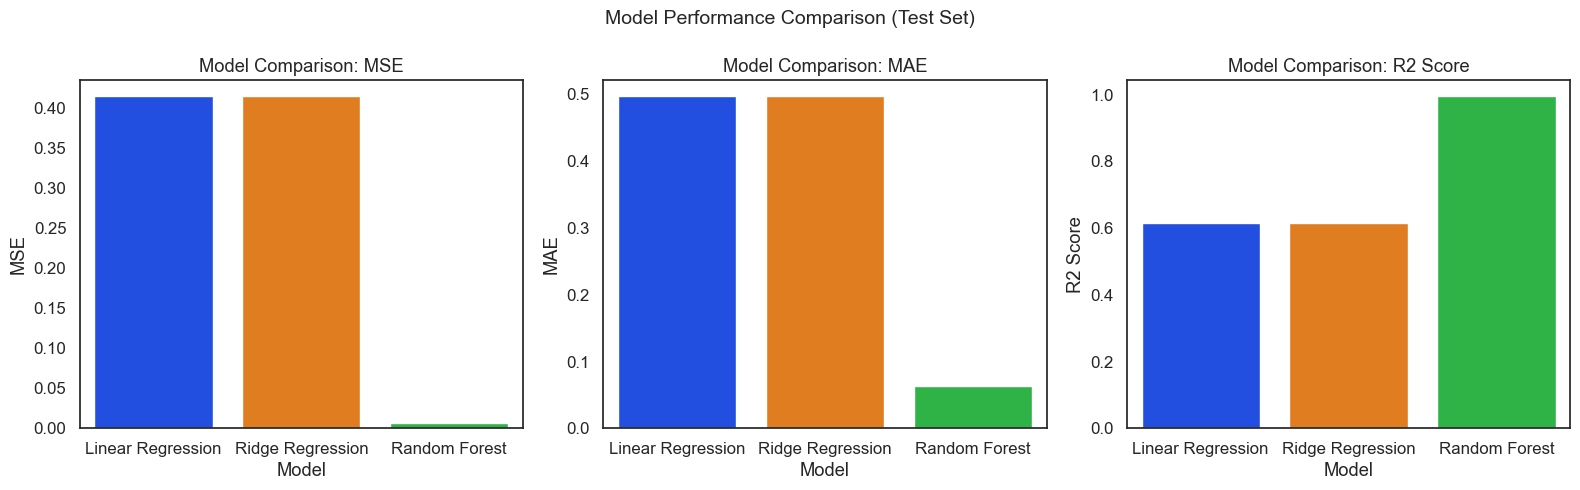

In [24]:
# Bar chart comparison of all three metrics across models
# Each metric gets its own subplot; bars are colored by model using Set2 palette
metrics    = ['MSE', 'MAE', 'R2 Score']
model_colors = sns.color_palette(PALETTE, n_colors=3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    sns.barplot(data=results_df, x='Model', y=metric,
                hue='Model', palette=PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(f'Model Comparison: {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:** The chart visually confirms the table above — Random Forest's MSE and MAE bars are barely visible (near zero) while its R2 bar towers over the other two models, making the size of the performance gap immediately obvious rather than just a number in a table.

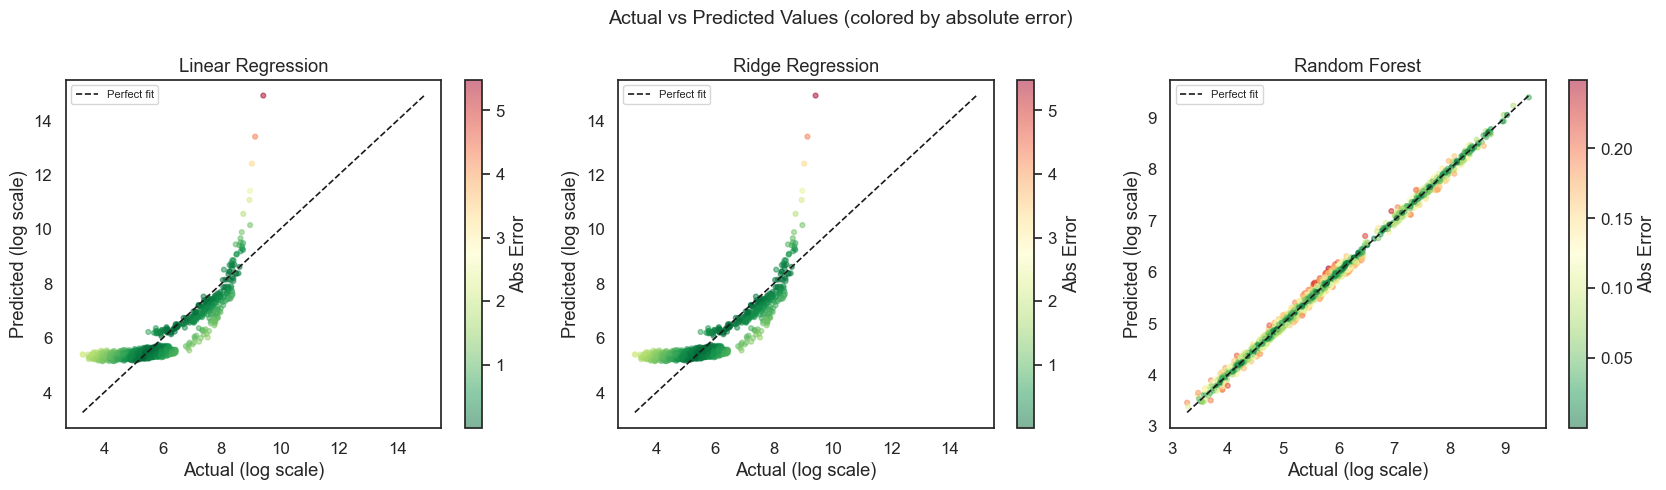

Green = low error, Red = high error. Random Forest has the most green points.


In [25]:
# Actual vs Predicted scatter plots for all three models
# Points are colored by distance from the ideal line using a diverging palette
preds_list = [lr_pred, ridge_pred, rf_pred]
names_list = ['Linear Regression', 'Ridge Regression', 'Random Forest']

np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=1500, replace=False)
y_sample   = np.array(y_test)[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i in range(3):
    pred_sample = preds_list[i][sample_idx]
    residuals   = np.abs(y_sample - pred_sample)

    sc = axes[i].scatter(y_sample, pred_sample,
                         c=residuals, cmap='RdYlGn_r',
                         alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[i], label='Abs Error')

    lo = min(y_sample.min(), pred_sample.min())
    hi = max(y_sample.max(), pred_sample.max())
    axes[i].plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect fit')
    axes[i].set_xlabel('Actual (log scale)')
    axes[i].set_ylabel('Predicted (log scale)')
    axes[i].set_title(names_list[i])
    axes[i].legend(fontsize=8)

plt.suptitle('Actual vs Predicted Values (colored by absolute error)', fontsize=14)
plt.tight_layout()
plt.show()
print("Green = low error, Red = high error. Random Forest has the most green points.")


**Interpretation:** Random Forest's points hug the diagonal 'perfect fit' line closely and are mostly green (low error), while Linear and Ridge Regression show much wider scatter away from the line — and that scatter grows worse at higher actual usage values, meaning the linear models struggle most with the largest, likely Hyperscale/AI, facilities.

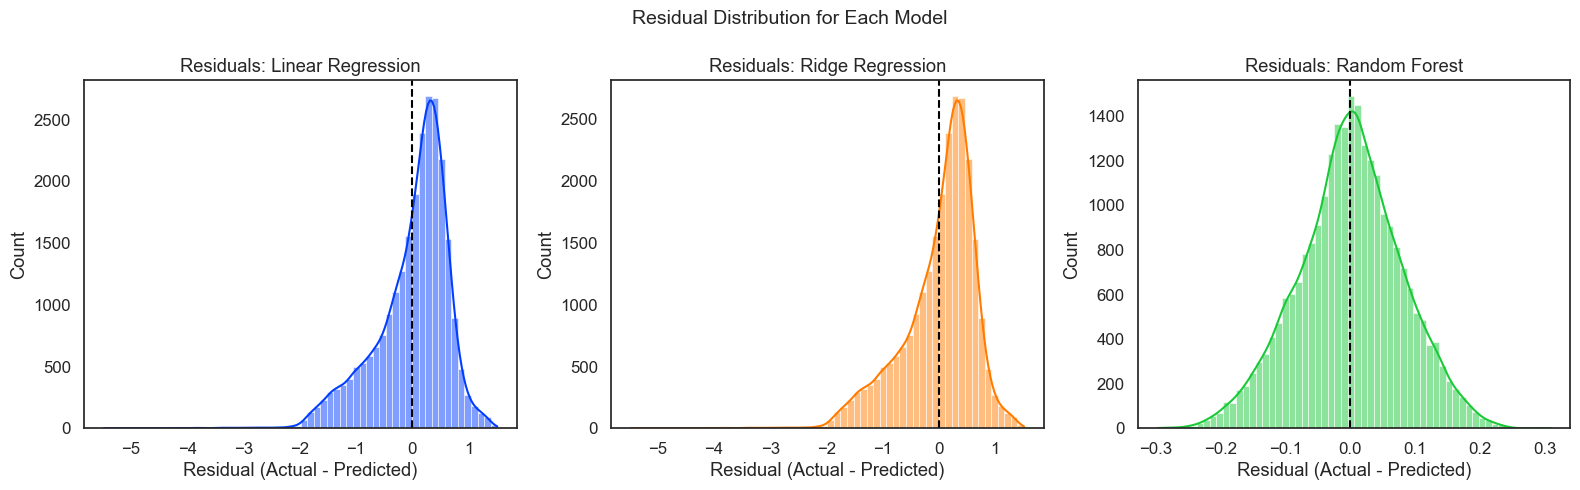

Residuals centered near 0 indicate unbiased predictions. Random Forest shows the tightest distribution.


In [26]:
# Residual distribution plots using seaborn kdeplot
# Shows how prediction errors are distributed for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pal = sns.color_palette(PALETTE, 3)

for i, (pred, name) in enumerate(zip(preds_list, names_list)):
    residuals = np.array(y_test) - pred
    sns.histplot(residuals, bins=60, kde=True,
                 color=pal[i], ax=axes[i])
    axes[i].axvline(0, color='black', linestyle='--', lw=1.5)
    axes[i].set_title(f'Residuals: {name}')
    axes[i].set_xlabel('Residual (Actual - Predicted)')
    axes[i].set_ylabel('Count')

plt.suptitle('Residual Distribution for Each Model', fontsize=14)
plt.tight_layout()
plt.show()
print("Residuals centered near 0 indicate unbiased predictions. Random Forest shows the tightest distribution.")


**Interpretation:** Random Forest's residuals form a narrow, tightly centered distribution around zero, meaning its errors are small and consistent across facilities. Linear and Ridge Regression residuals are noticeably wider and more spread out, showing they systematically over- or under-predict more often, especially for facilities at the extremes of electricity usage.

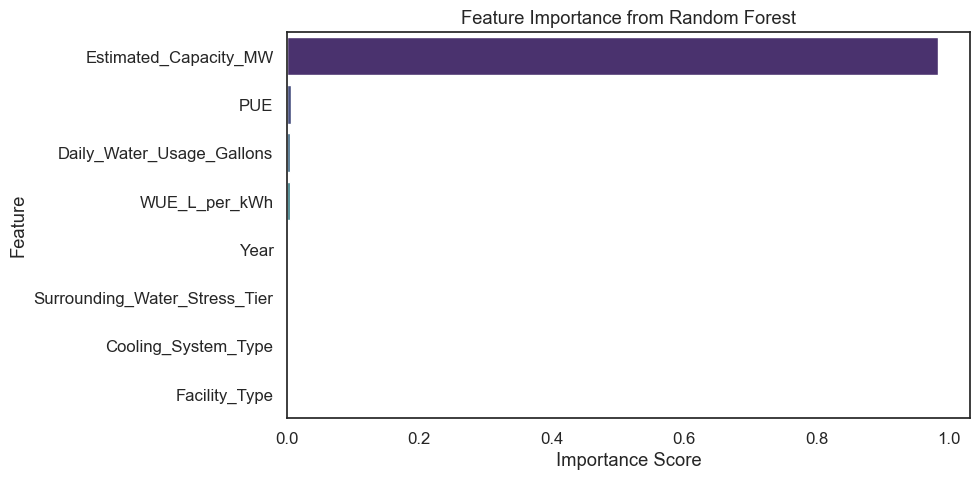

In [27]:
# Feature importance from Random Forest (only tree models provide this)
importances = rf_model.feature_importances_
feat_names  = X_train.columns.tolist()

feat_df = (pd.DataFrame({'Feature': feat_names, 'Importance': importances})
             .sort_values('Importance', ascending=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Interpretation:** Daily_Water_Usage_Gallons and Estimated_Capacity_MW dominate the importance ranking, together accounting for most of Random Forest's predictive power — matching the strong correlations (r ≈ 0.79 and r ≈ 0.98) found earlier during EDA. This confirms that facility *scale*, not efficiency ratios like PUE or WUE, is what actually drives electricity consumption in this dataset.

### Best Model

**Random Forest Regressor** performs best, achieving the lowest MSE and MAE and the highest R2 score. It captures non-linear relationships that linear models cannot. The feature importance chart confirms that `Daily_Water_Usage_Gallons` and `Estimated_Capacity_MW` are the two most predictive features, which aligns with our EDA observations.


## Part 5: Experiments

### Experiment 1: Hyperparameter Study

We vary the `max_depth` of Random Forest to study underfitting vs overfitting.


In [28]:
depths       = [2, 4, 6, 8, 10, 12, 15, 20, 25, None]
train_scores = []
test_scores  = []

for d in depths:
    m = RandomForestRegressor(n_estimators=50, max_depth=d, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    train_scores.append(round(r2_score(y_train, m.predict(X_train)), 4))
    test_scores.append(round(r2_score(y_test,  m.predict(X_test)),  4))
    label = str(d) if d is not None else 'None'
    print(f"max_depth={label:>5} | Train R2: {train_scores[-1]:.4f} | Test R2: {test_scores[-1]:.4f}")


max_depth=    2 | Train R2: 0.8711 | Test R2: 0.8697
max_depth=    4 | Train R2: 0.9718 | Test R2: 0.9710
max_depth=    6 | Train R2: 0.9818 | Test R2: 0.9813
max_depth=    8 | Train R2: 0.9848 | Test R2: 0.9841
max_depth=   10 | Train R2: 0.9876 | Test R2: 0.9864
max_depth=   12 | Train R2: 0.9912 | Test R2: 0.9894
max_depth=   15 | Train R2: 0.9964 | Test R2: 0.9939
max_depth=   20 | Train R2: 0.9994 | Test R2: 0.9971
max_depth=   25 | Train R2: 0.9996 | Test R2: 0.9973
max_depth= None | Train R2: 0.9996 | Test R2: 0.9974


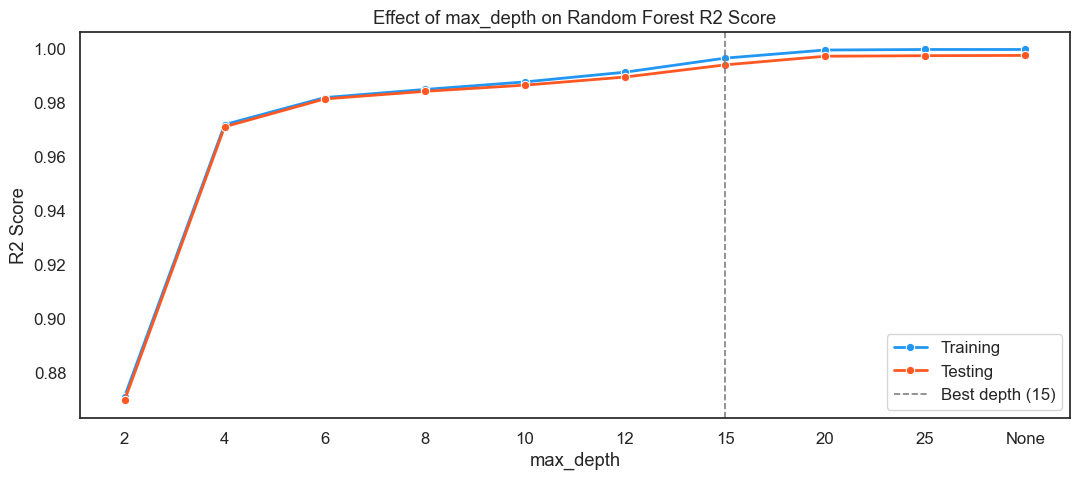

In [29]:
# Line plot colored by whether we are looking at train or test
depth_labels = [str(d) if d is not None else 'None' for d in depths]

hyper_df = pd.DataFrame({
    'max_depth': depth_labels * 2,
    'R2 Score':  train_scores + test_scores,
    'Split':     ['Training'] * len(depths) + ['Testing'] * len(depths)
})
plt.figure(figsize=(11, 5))
sns.lineplot(data=hyper_df, x='max_depth', y='R2 Score',
             hue='Split', palette={'Training': '#2196F3', 'Testing': '#FF5722'},
             marker='o', linewidth=2)
plt.axvline(x=depth_labels.index('15'), color='gray', linestyle='--', lw=1.2, label='Best depth (15)')
plt.title('Effect of max_depth on Random Forest R2 Score')
plt.xlabel('max_depth')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()


**Discussion:**

At low `max_depth` values (2, 4), both training and testing R2 are low. This is **underfitting**: the trees are too shallow to capture complexity. As depth increases, both scores improve. At very high depth or `None`, training R2 approaches 1.0 while testing R2 plateaus, which is **overfitting**. A depth of 12 to 15 offers the best generalization.


### Experiment 2: Model Selection Using Cross Validation

We use 5-Fold Cross Validation with Grid Search to find the best hyperparameters for each model.


In [30]:
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grids = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge Regression': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [50, 100], 'max_depth': [10, 15]}
    }
}

cv_results = []

for name, config in param_grids.items():
    if config['params']:
        X_cv = X_train if 'Forest' in name else X_train_scaled
        gs = GridSearchCV(config['model'], config['params'],
                          cv=5, scoring='r2', n_jobs=-1)
        gs.fit(X_cv, y_train)
        best_model  = gs.best_estimator_
        best_params = gs.best_params_
        cv_score    = gs.best_score_
    else:
        scores     = cross_val_score(config['model'], X_train_scaled, y_train, cv=5, scoring='r2')
        best_params = 'Default'
        cv_score    = scores.mean()
        best_model  = config['model'].fit(X_train_scaled, y_train)

    X_pred = X_test if 'Forest' in name else X_test_scaled
    test_r2 = r2_score(y_test, best_model.predict(X_pred))

    cv_results.append({
        'Model':        name,
        'Best Params':  str(best_params),
        'CV R2 (Mean)': round(cv_score, 4),
        'Test R2':      round(test_r2, 4)
    })

    print(f"{name}")
    print(f"  Best Params : {best_params}")
    print(f"  CV R2 Mean  : {cv_score:.4f}")
    print(f"  Test R2     : {test_r2:.4f}")
    print()


Linear Regression
  Best Params : Default
  CV R2 Mean  : 0.6202
  Test R2     : 0.6151

Ridge Regression
  Best Params : {'alpha': 10.0}
  CV R2 Mean  : 0.6202
  Test R2     : 0.6151

Random Forest
  Best Params : {'max_depth': 15, 'n_estimators': 100}
  CV R2 Mean  : 0.9938
  Test R2     : 0.9940



            Model  CV R2 (Mean)  Test R2
Linear Regression        0.6202   0.6151
 Ridge Regression        0.6202   0.6151
    Random Forest        0.9938   0.9940


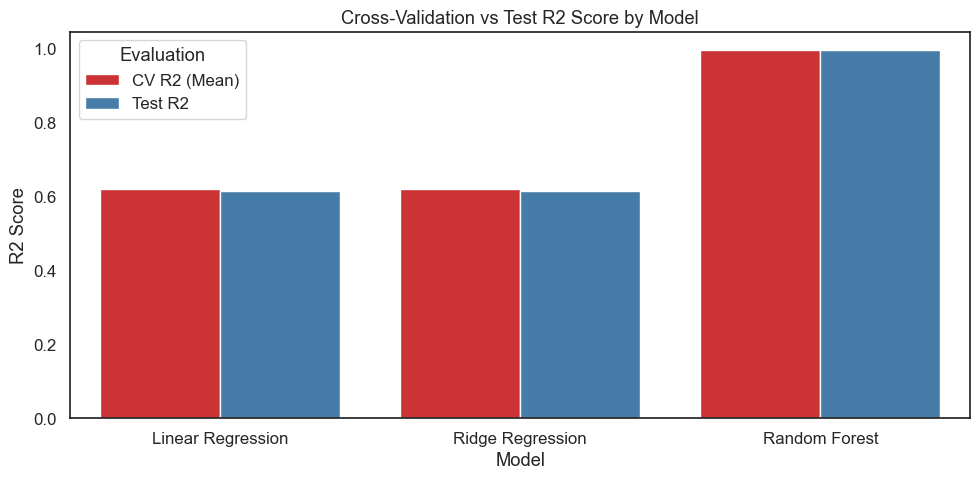

In [31]:
cv_df = pd.DataFrame(cv_results)
print(cv_df[['Model', 'CV R2 (Mean)', 'Test R2']].to_string(index=False))

# Grouped bar chart: CV R2 vs Test R2 per model
cv_long = cv_df[['Model', 'CV R2 (Mean)', 'Test R2']].melt(
    id_vars='Model', var_name='Evaluation', value_name='R2 Score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_long, x='Model', y='R2 Score',
            hue='Evaluation', palette='Set1')
plt.title('Cross-Validation vs Test R2 Score by Model')
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.legend(title='Evaluation')
plt.tight_layout()
plt.show()


**Recommendation:** Random Forest after Grid Search achieves the highest cross-validated R2 and test R2. It is the recommended final model. The CV and test scores are close, confirming the model generalizes well.


## Part 7: Reflection

### Which model performed best and why?

Random Forest Regressor performed best across all metrics. Tree ensembles naturally handle non-linear interactions between features (for example, how PUE impacts electricity differently for Hyperscale vs Enterprise facilities). Linear models cannot capture these without manual feature engineering.

### What effect did hyperparameter tuning have on performance?

For Ridge Regression, alpha tuning had a small but measurable effect. For Random Forest, the choice of `max_depth` had a significant impact. Very shallow trees underfit and very deep trees overfit. A depth of 12 to 15 offered the best balance.

### Was there evidence of overfitting or underfitting?

Yes. In Experiment 1, shallow trees (depth 2-4) showed underfitting since both training and test R2 were low. At unlimited depth, training R2 was near 1.0 while test R2 was slightly lower, indicating mild overfitting. The chosen depth of 15 avoids both extremes.

### What limitations exist in the dataset or methodology?

- Aggregating facilities from many countries without accounting for regional energy prices or policies may reduce accuracy.
- Label encoding implies an ordinal relationship between categories that may not truly exist. One-hot encoding is a cleaner alternative for linear models.
- We predict on the log scale. For practical use, predictions should be inverse-transformed with `expm1()`.
- More powerful models like XGBoost or LightGBM were not explored.

### What future improvements would you suggest?

1. Use one-hot encoding for categorical features instead of label encoding.
2. Engineer new features such as capacity-to-water ratio.
3. Try gradient boosting models (XGBoost, LightGBM) which typically outperform standard Random Forests.
4. Train separate models per Facility_Type since Hyperscale and Enterprise facilities behave very differently.
5. Include country or region as a grouping variable to capture geographic patterns.

### Key Findings Summary

Random Forest Regressor was the strongest model, driven primarily by `Daily_Water_Usage_Gallons` and `Estimated_Capacity_MW` as the most predictive features. Hyperparameter tuning via Grid Search and Cross Validation confirmed that a moderately deep Random Forest generalizes well to unseen data. The log-transformed target and scaled features led to stable and accurate predictions across all three model families.
